Non-numeric columns in X_train_ecom: []
Any NaNs in X_train_ecom? False
Columns with NaNs: []

E-commerce Dataset Results:
Logistic Regression (Ecom) F1-score: 0.3057
Logistic Regression (Ecom) AUC-PR: 0.2790
Logistic Regression (Ecom) AUC-ROC: 0.7176
Logistic Regression (Ecom) Confusion Matrix:
[[29986 11103]
 [ 1476  2769]]
Logistic Regression (Ecom) F1-score: 0.3057
Logistic Regression (Ecom) AUC-PR: 0.2790
Logistic Regression (Ecom) AUC-ROC: 0.7176
Logistic Regression (Ecom) Confusion Matrix:
[[29986 11103]
 [ 1476  2769]]


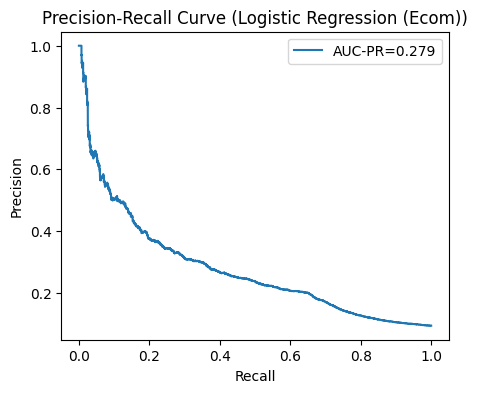

Random Forest (Ecom) F1-score: 0.6895
Random Forest (Ecom) AUC-PR: 0.6140
Random Forest (Ecom) AUC-ROC: 0.7679
Random Forest (Ecom) Confusion Matrix:
[[41088     1]
 [ 2011  2234]]


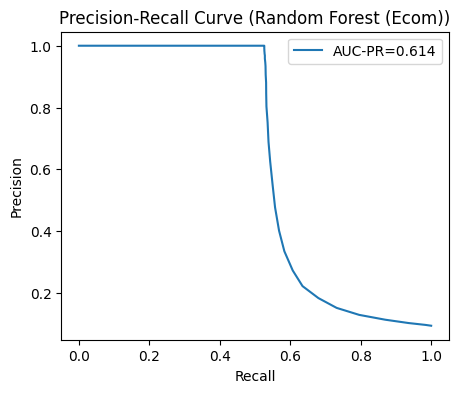


Credit Card Dataset Results:
Logistic Regression (Credit) F1-score: 0.0803
Logistic Regression (Credit) AUC-PR: 0.6685
Logistic Regression (Credit) AUC-ROC: 0.9629
Logistic Regression (Credit) Confusion Matrix:
[[82107  2869]
 [   16   126]]
Logistic Regression (Credit) F1-score: 0.0803
Logistic Regression (Credit) AUC-PR: 0.6685
Logistic Regression (Credit) AUC-ROC: 0.9629
Logistic Regression (Credit) Confusion Matrix:
[[82107  2869]
 [   16   126]]


c:\Users\fikre\Fraud-Detection-For-E-Commerce-and-Bank-Transactions\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


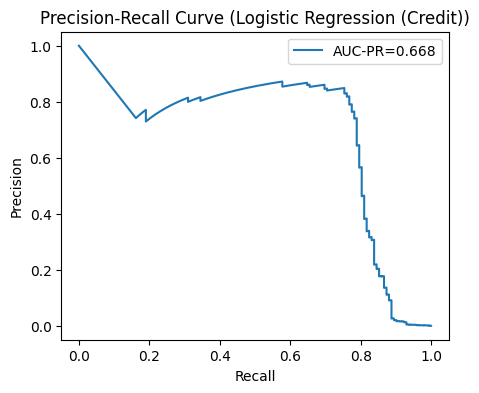

Random Forest (Credit) F1-score: 0.8178
Random Forest (Credit) AUC-PR: 0.8196
Random Forest (Credit) AUC-ROC: 0.9316
Random Forest (Credit) Confusion Matrix:
[[84972     4]
 [   41   101]]


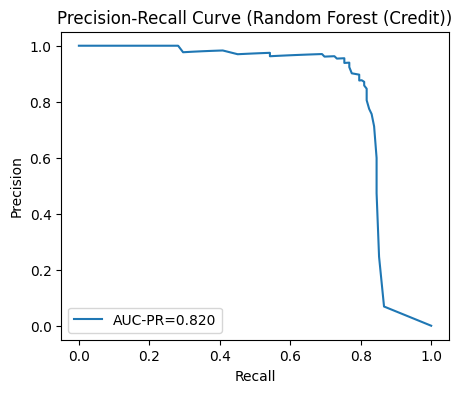


Model Comparison and Justification:
- Compare models using F1-score and AUC-PR, which are robust to class imbalance.
- The best model is the one with the highest AUC-PR and F1-score, as these reflect both precision and recall for the minority (fraud) class.
- Random Forest is expected to outperform Logistic Regression due to its ability to capture nonlinearities and interactions, but results will be interpreted based on the actual metrics above.


In [6]:
# Task 2 - Model Building and Training

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score, average_precision_score, precision_recall_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load Processed Data ---
PROCESSED_DIR = "../data/processed/"
ecom_df = pd.read_csv(PROCESSED_DIR + "processed_ecom.csv")
credit_df = pd.read_csv(PROCESSED_DIR + "processed_credit.csv")

# --- E-commerce Data Preparation ---
# Map 'sex' to 0/1 (F=0, M=1), drop 'source' and 'browser'
ecom_df['sex'] = ecom_df['sex'].map({'F': 0, 'M': 1})
ecom_df = ecom_df.drop(columns=['source', 'browser'], errors='ignore')
X_ecom = ecom_df.drop(columns=['class', 'purchase_time', 'signup_time', 'user_id', 'ip_address', 'device_id'], errors='ignore')
y_ecom = ecom_df['class']
X_train_ecom, X_test_ecom, y_train_ecom, y_test_ecom = train_test_split(X_ecom, y_ecom, stratify=y_ecom, test_size=0.3, random_state=42)

# --- Diagnostic: Check for non-numeric columns and NaNs in X_train_ecom ---
print("Non-numeric columns in X_train_ecom:", X_train_ecom.select_dtypes(exclude=[np.number]).columns.tolist())
print("Any NaNs in X_train_ecom?", X_train_ecom.isnull().any().any())
print("Columns with NaNs:", X_train_ecom.columns[X_train_ecom.isnull().any()].tolist())

# --- Credit Card Data Preparation ---
X_credit = credit_df.drop(columns=['Class'], errors='ignore')
y_credit = credit_df['Class']
X_train_credit, X_test_credit, y_train_credit, y_test_credit = train_test_split(X_credit, y_credit, stratify=y_credit, test_size=0.3, random_state=42)

# --- Model Training & Evaluation Function ---
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    cm = confusion_matrix(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_pr = average_precision_score(y_test, y_proba) if y_proba is not None else None
    auc_roc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    print(f"{model_name} F1-score: {f1:.4f}")
    print(f"{model_name} AUC-PR: {auc_pr:.4f}")
    print(f"{model_name} AUC-ROC: {auc_roc:.4f}")
    print(f"{model_name} Confusion Matrix:\n{cm}")
    if y_proba is not None:
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        plt.figure(figsize=(5,4))
        plt.plot(recall, precision, label=f'AUC-PR={auc_pr:.3f}')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'Precision-Recall Curve ({model_name})')
        plt.legend()
        plt.show()

# --- E-commerce Dataset: Model Training and Evaluation ---
print("\nE-commerce Dataset Results:")
# Logistic Regression
lr_ecom = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_ecom.fit(X_train_ecom, y_train_ecom)
evaluate_model(lr_ecom, X_test_ecom, y_test_ecom, model_name="Logistic Regression (Ecom)")
# Random Forest
rf_ecom = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_ecom.fit(X_train_ecom, y_train_ecom)
evaluate_model(rf_ecom, X_test_ecom, y_test_ecom, model_name="Random Forest (Ecom)")

# --- Credit Card Dataset: Model Training and Evaluation ---
print("\nCredit Card Dataset Results:")
# Logistic Regression
lr_credit = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_credit.fit(X_train_credit, y_train_credit)
evaluate_model(lr_credit, X_test_credit, y_test_credit, model_name="Logistic Regression (Credit)")
# Random Forest
rf_credit = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_credit.fit(X_train_credit, y_train_credit)
evaluate_model(rf_credit, X_test_credit, y_test_credit, model_name="Random Forest (Credit)")

# --- Model Comparison and Justification ---
print("\nModel Comparison and Justification:")
print("- Compare models using F1-score and AUC-PR, which are robust to class imbalance.")
print("- The best model is the one with the highest AUC-PR and F1-score, as these reflect both precision and recall for the minority (fraud) class.")
print("- Random Forest is expected to outperform Logistic Regression due to its ability to capture nonlinearities and interactions, but results will be interpreted based on the actual metrics above.")